In [1]:
from pathlib import Path
import wave
import contextlib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util
import subprocess
import sys
import matplotlib.pyplot as plt
import numpy as np


# Base folder that contains class subfolders (asthma, copd, etc.)
base_data_dir = Path("data")

label_map = {
    "asthma": "Asthma",
    "copd": "COPD",
    "bronchial": "Bronchial",
    "pneumonia": "Pneumonia",
    "healthy": "Healthy",
}

rows = []

for wav_path in base_data_dir.rglob("*.wav"):
    folder_name = wav_path.parent.name.lower()
    label = label_map.get(folder_name, wav_path.parent.name)

    with contextlib.closing(wave.open(str(wav_path), "rb")) as wav_file:
        sample_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        duration_sec = n_frames / float(sample_rate) if sample_rate else 0.0

    # Relative path inside the stage after PUT data/*.wav @audio_stage
    file_path = str(wav_path.as_posix())

    rows.append(
        {
            "file_name": wav_path.name,
            "label": label,
            "duration_sec": duration_sec,
            "sample_rate": sample_rate,
            "file_path": file_path,
        }
    )

df = pd.DataFrame(rows).sort_values(["label", "file_name"]).reset_index(drop=True)
df

,file_name,label,duration_sec,sample_rate,file_path
0,P10AsthmaIE_49.wav,Asthma,3.136000,4000,data/asthma/P10AsthmaIE_49.wav
1,P10AsthmaIU_46.wav,Asthma,4.944000,4000,data/asthma/P10AsthmaIU_46.wav
2,P10AsthmaIU_50.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaIU_50.wav
3,P10AsthmaRL_47.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaRL_47.wav
4,P10AsthmaRS_48.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaRS_48.wav
...,...,...,...,...,...
1206,P9Pneumonia63O.wav,Pneumonia,4.922154,44100,data/pneumonia/P9Pneumonia63O.wav
1207,P9Pneumonia67I.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia67I.wav
1208,P9Pneumonia73J.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia73J.wav
1209,P9Pneumonia74S.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia74S.wav


In [2]:
df['label'].value_counts()

label
COPD         401
Asthma       288
Pneumonia    285
Healthy      133
Bronchial    104
Name: count, dtype: int64

In [3]:
df['sample_rate'].value_counts()

sample_rate
44100    707
4000     504
Name: count, dtype: int64

In [4]:
df[df['sample_rate'] != 4000]['label'].value_counts()

label
Pneumonia    246
COPD         213
Healthy      133
Bronchial     89
Asthma        26
Name: count, dtype: int64

In [5]:
df[df['duration_sec'] <= 4]['label'].value_counts()

label
Asthma       6
Bronchial    3
Pneumonia    1
Name: count, dtype: int64

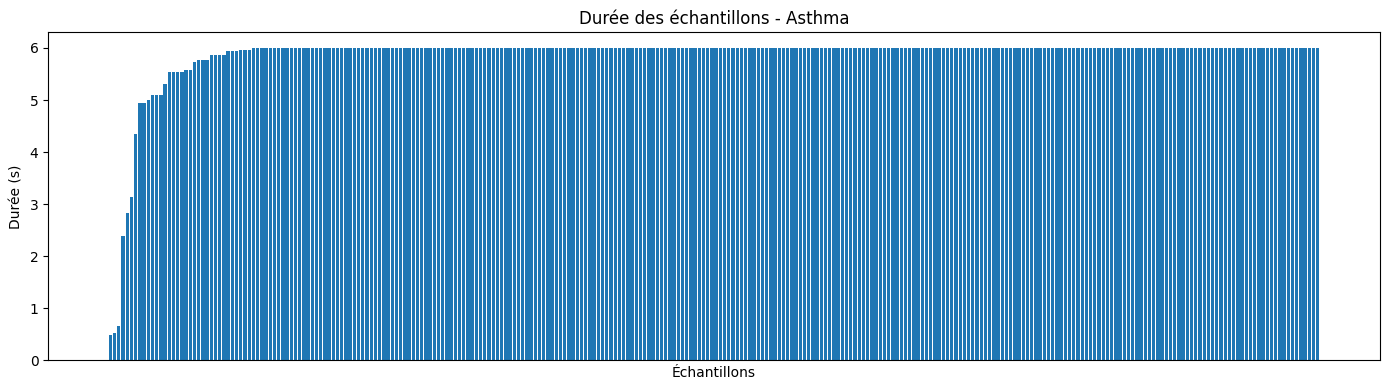

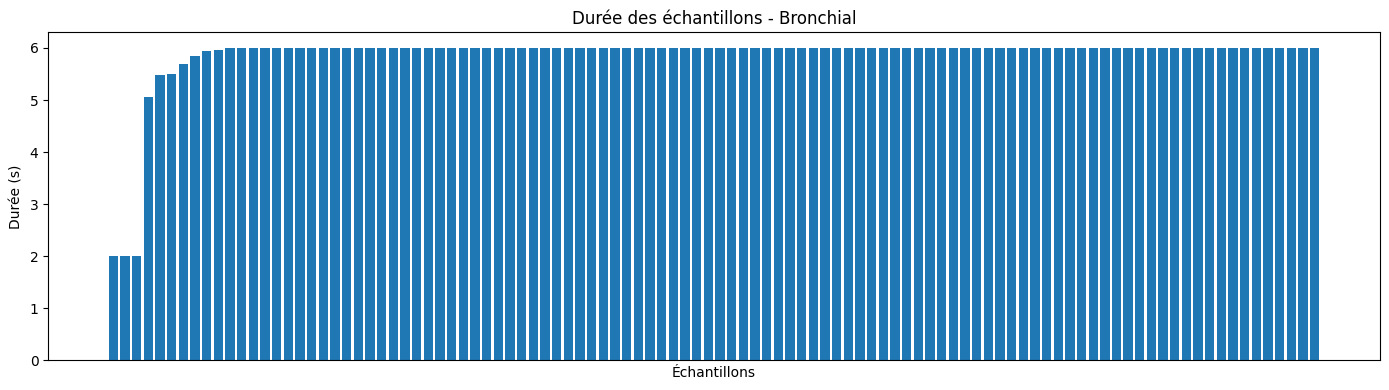

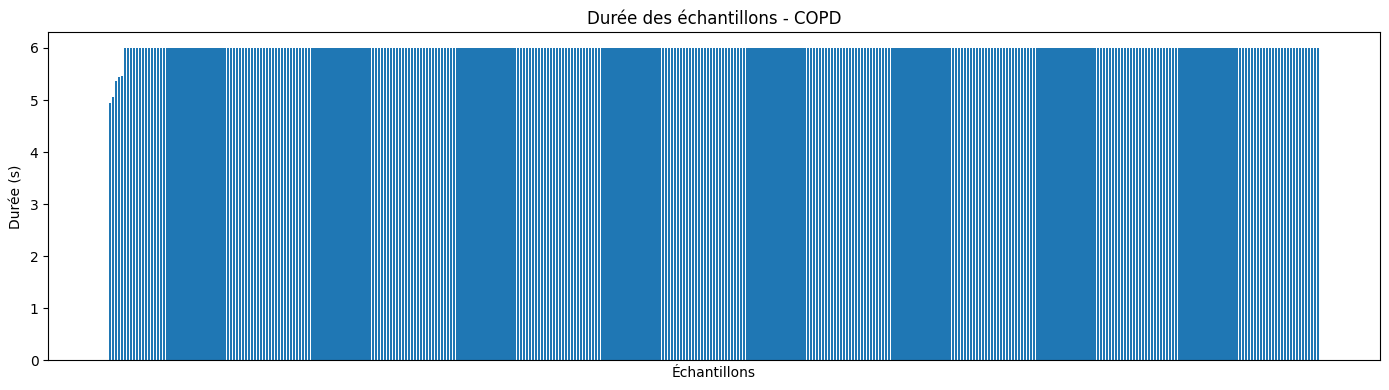

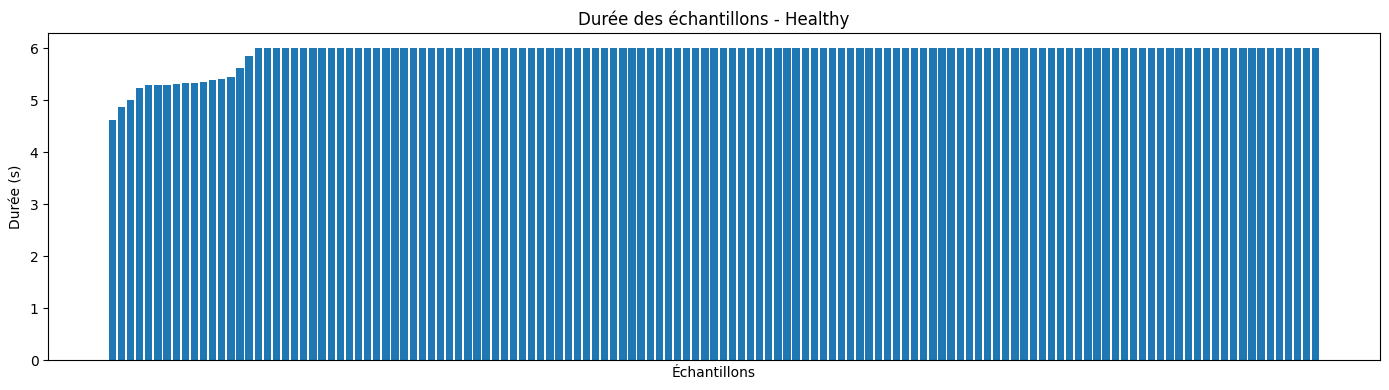

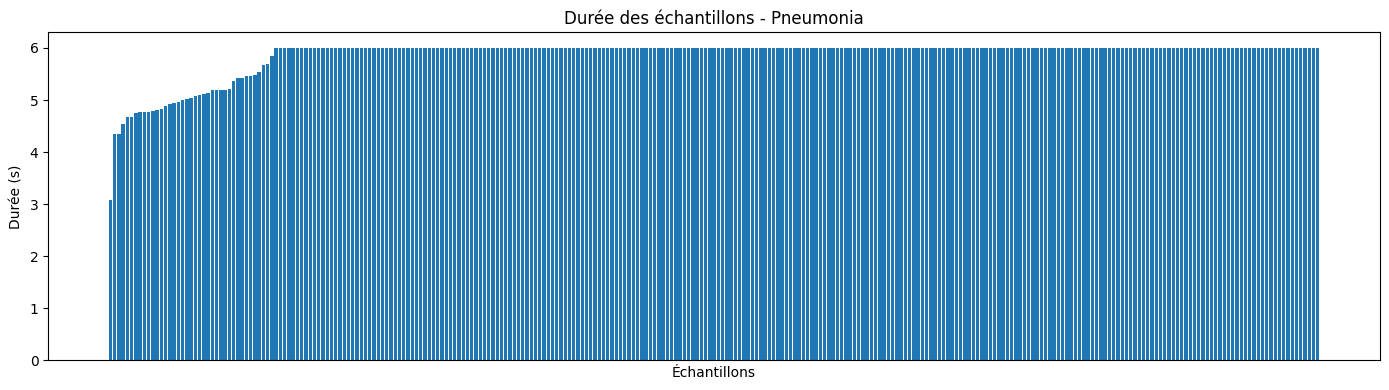

In [6]:
# montre les durées en fonction des labels avec mlp
df.groupby('label')['duration_sec'].describe()
for label, group in df.groupby("label"):
    group = group.sort_values("duration_sec").reset_index(drop=True)

    plt.figure(figsize=(14, 4))
    plt.bar(group["file_name"], group["duration_sec"])
    plt.title(f"Durée des échantillons - {label}")
    plt.xlabel("Échantillons")
    plt.ylabel("Durée (s)")
    plt.xticks([])  # trop de noms de fichiers à afficher
    plt.tight_layout()
    plt.show()

# VIsualisation

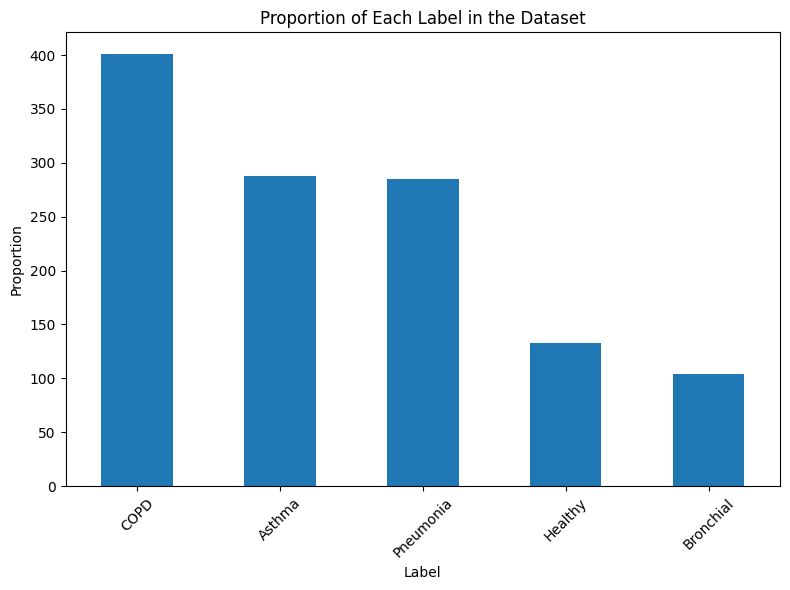

In [7]:
label_counts = df["label"].value_counts()
label_proportions = label_counts / label_counts.sum()
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
label_counts.plot(kind="bar")
plt.title("Proportion of Each Label in the Dataset")
plt.xlabel("Label")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Création des spectres


=== Waveform Examples for Each Category (Normalized Y scale) ===


c:\Users\Paul\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


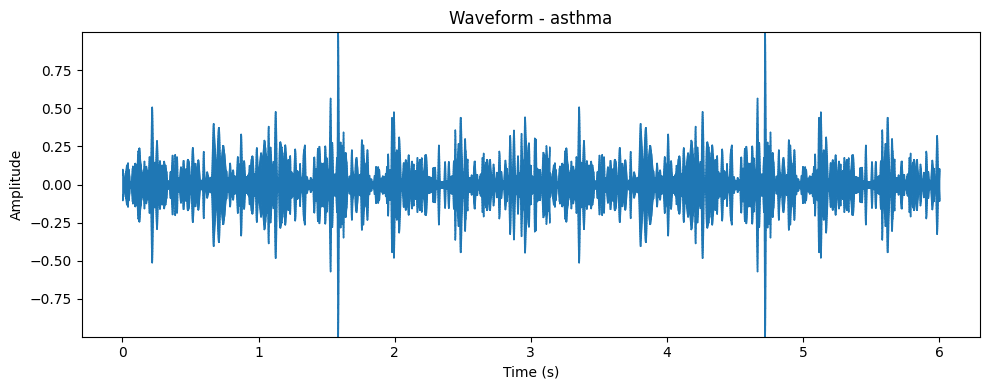

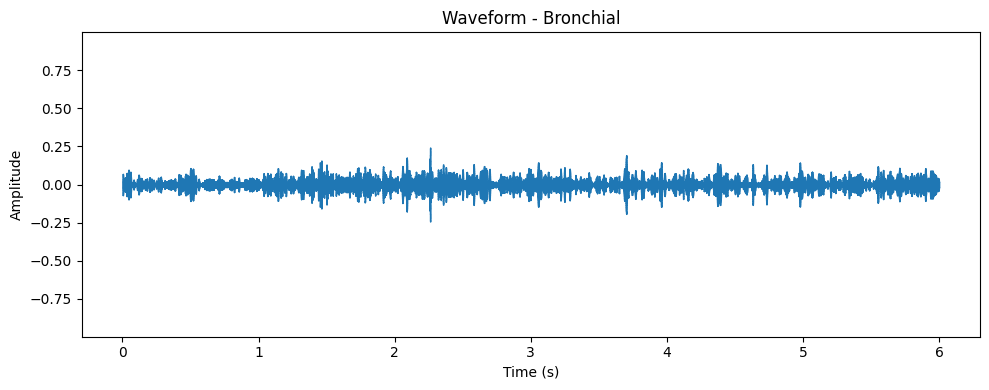

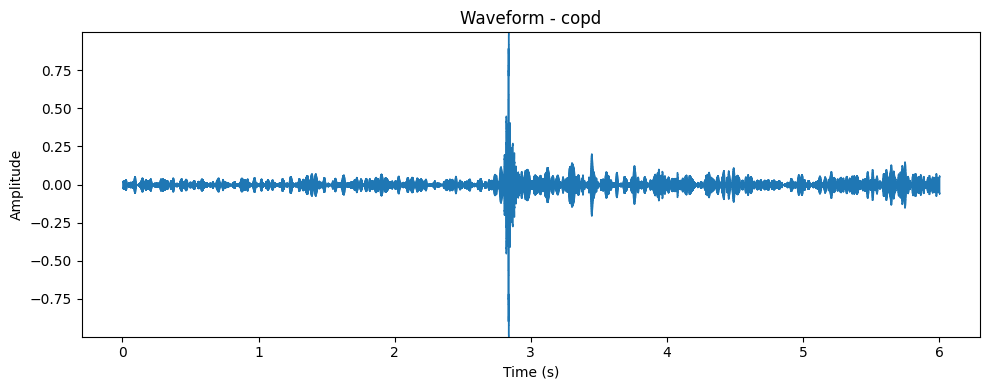

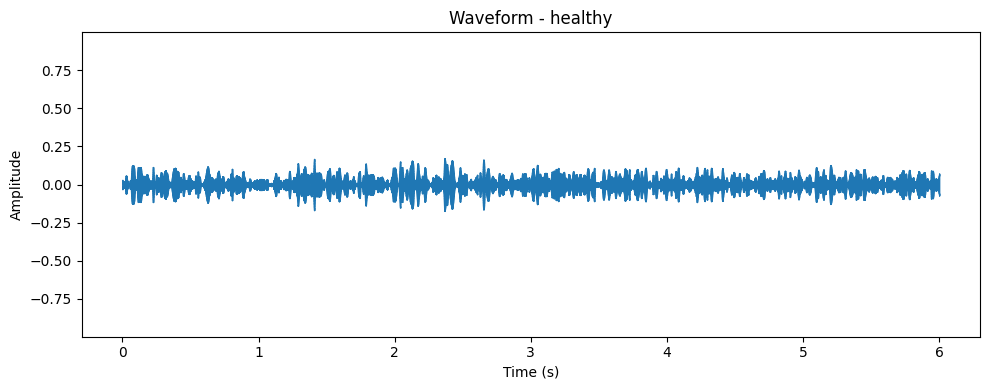

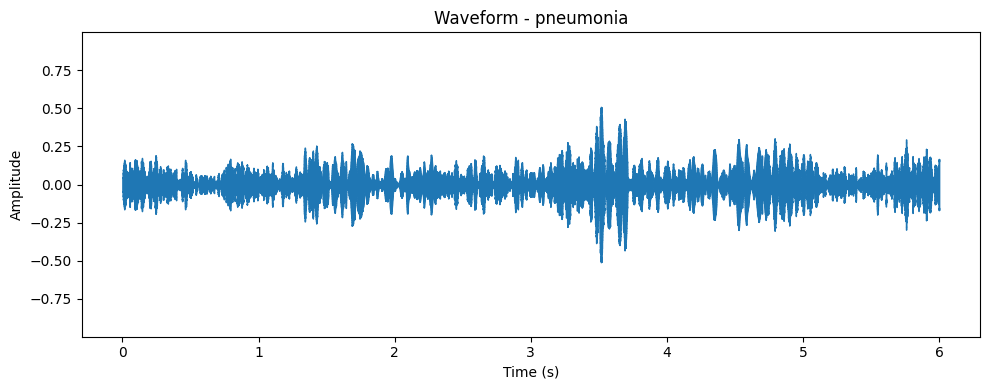

In [8]:
def show_waveform_examples(base_data_dir="data", index=0, categories=None):
    base_data_dir = Path(base_data_dir)

    if categories is None:
        categories = ["asthma", "Bronchial", "copd", "healthy", "pneumonia"]

    category_dirs = [base_data_dir / category for category in categories]

    print("\n=== Waveform Examples for Each Category (Normalized Y scale) ===")
    loaded_waveforms = []

    for category_dir in category_dirs:
        if not category_dir.exists():
            print(f"Folder not found: {category_dir}")
            continue

        wav_files = sorted(category_dir.glob("*.wav"))
        if not wav_files:
            print(f"No .wav file in: {category_dir}")
            continue

        audio_path = wav_files[index]
        y, sr = librosa.load(str(audio_path), sr=None)
        loaded_waveforms.append((category_dir.name, y, sr))

    if not loaded_waveforms:
        print("No waveform could be loaded from this dataset.")
        return []

    global_max_abs = max(float(np.max(np.abs(y))) for _, y, _ in loaded_waveforms)
    # Avoid invalid limits in edge cases (silent files)
    if global_max_abs == 0.0:
        global_max_abs = 1.0

    for category_name, y, sr in loaded_waveforms:
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.ylim(-global_max_abs, global_max_abs)
        plt.title(f"Waveform - {category_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()

    # return loaded_waveforms

show_waveform_examples(base_data_dir="data_updated")


=== Mel Spectrogram Examples for Each Category (Normalized Color Scale) ===


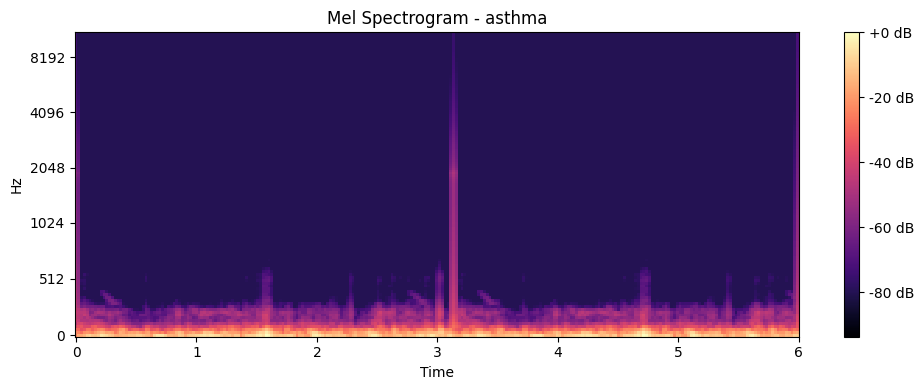

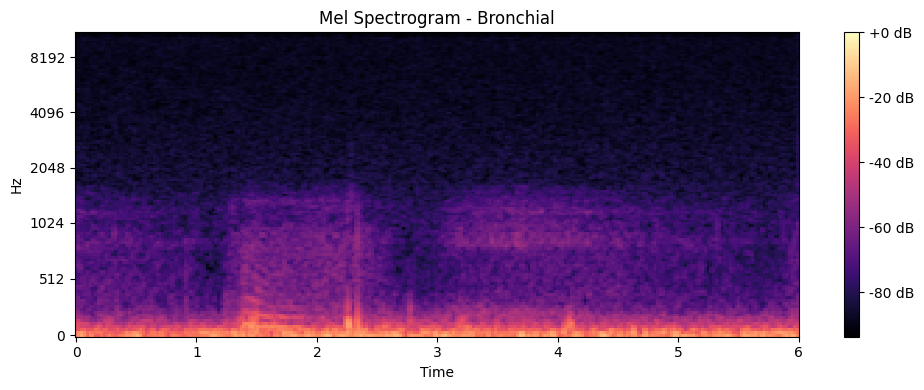

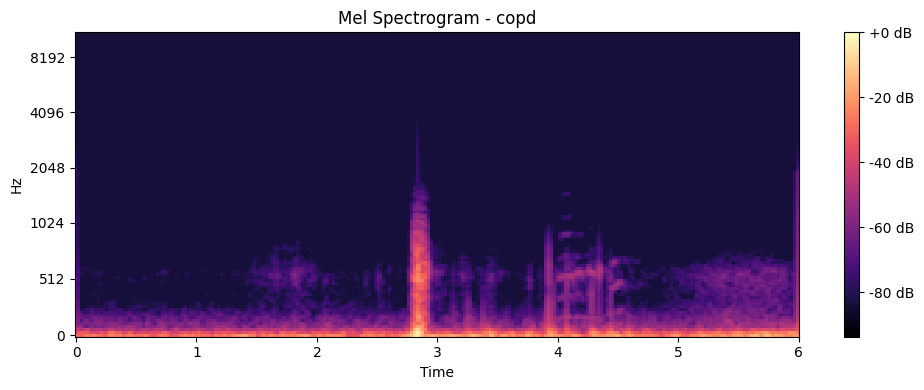

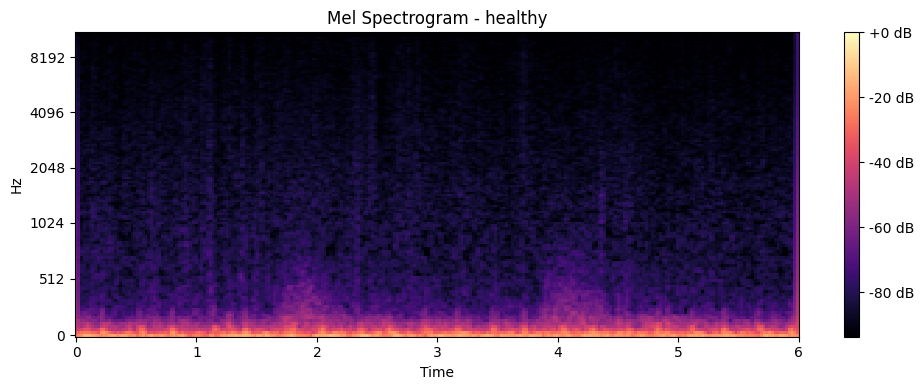

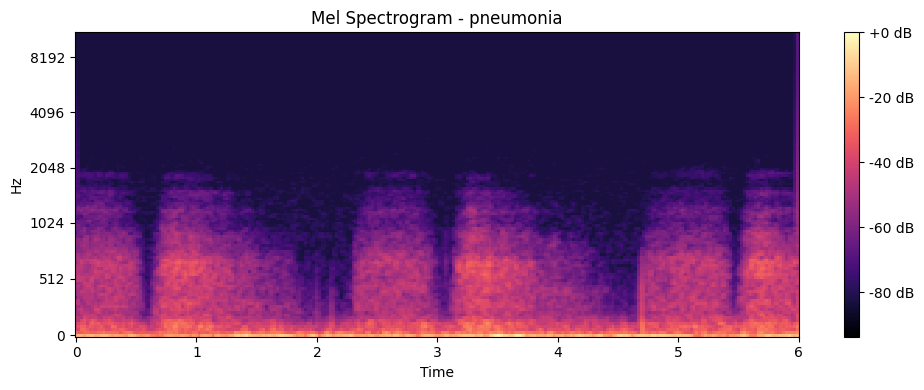

In [ ]:
# MEL, maybe a paramétriser pour tester plusieurs

def show_mel_spectrogram_examples(base_data_dir="data", index=0, categories=None):
    base_data_dir = Path(base_data_dir)

    if categories is None:
        categories = ["asthma", "Bronchial", "copd", "healthy", "pneumonia"]

    category_dirs = [base_data_dir / category for category in categories]

    print("\n=== Mel Spectrogram Examples for Each Category (Normalized Color Scale) ===")
    loaded_specs = []

    for category_dir in category_dirs:
        if not category_dir.exists():
            print(f"Folder not found: {category_dir}")
            continue

        wav_files = sorted(category_dir.glob("*.wav"))
        if not wav_files:
            print(f"No .wav file in: {category_dir}")
            continue

        audio_path = wav_files[index]  # file at the specified index for this category
        y, sr = librosa.load(str(audio_path), sr=None)
        mel_power = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        # n_fft : taille fenetre, petit = bonne précision temporelle, grand = meilleure analyse fréquentielle
        # hop_length : plus petit = meilleur
        loaded_specs.append((category_dir.name, mel_power, sr))

    if not loaded_specs:
        print("No mel spectrogram could be loaded from this dataset.")
        return []

    global_ref_power = max(float(np.max(mel_power)) for _, mel_power, _ in loaded_specs)
    mel_specs_db = [
        (category_name, librosa.power_to_db(mel_power, ref=global_ref_power), sr)
        for category_name, mel_power, sr in loaded_specs
    ]

    global_vmin = min(float(np.min(mel_db)) for _, mel_db, _ in mel_specs_db)
    global_vmax = 0.0

    for category_name, mel_db, sr in mel_specs_db:
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(
            mel_db,
            sr=sr,
            x_axis="time",
            y_axis="mel",
            vmin=global_vmin,
            vmax=global_vmax,
        )
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Mel Spectrogram - {category_name}")
        plt.tight_layout()
        plt.show()

    # return mel_specs_db

show_mel_spectrogram_examples(base_data_dir="data_updated")


=== MFCC Examples for Each Category (Normalized Color Scale) ===


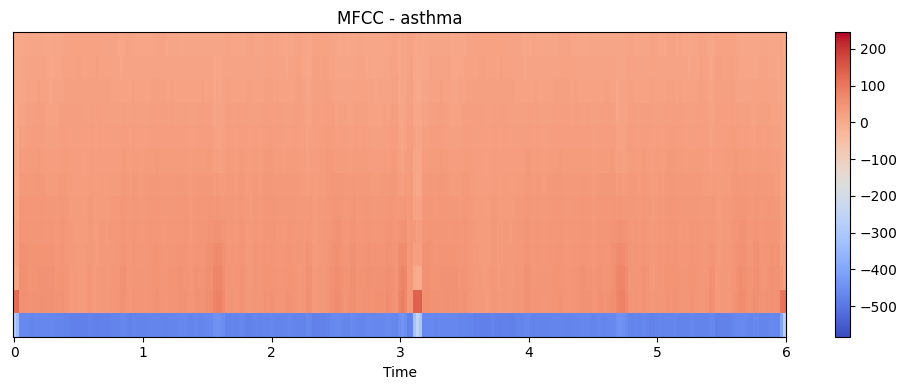

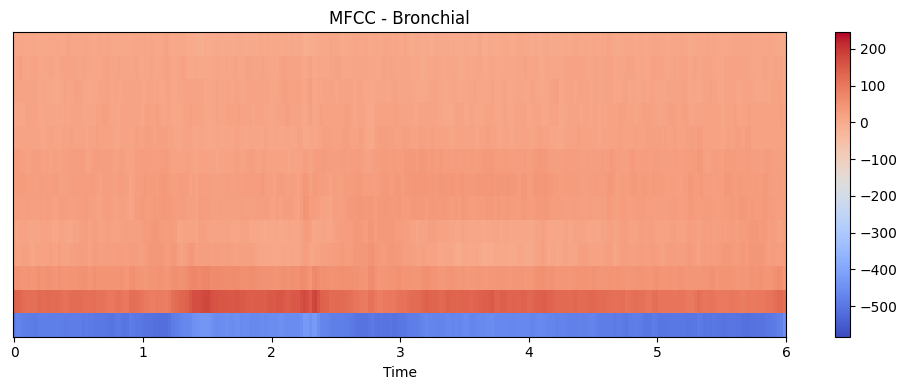

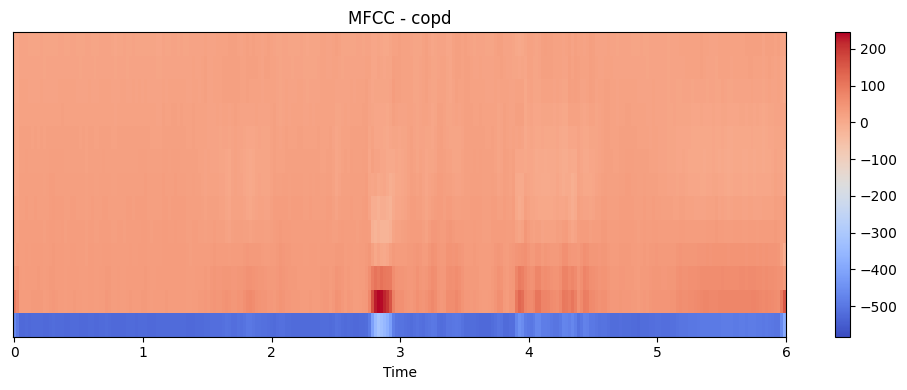

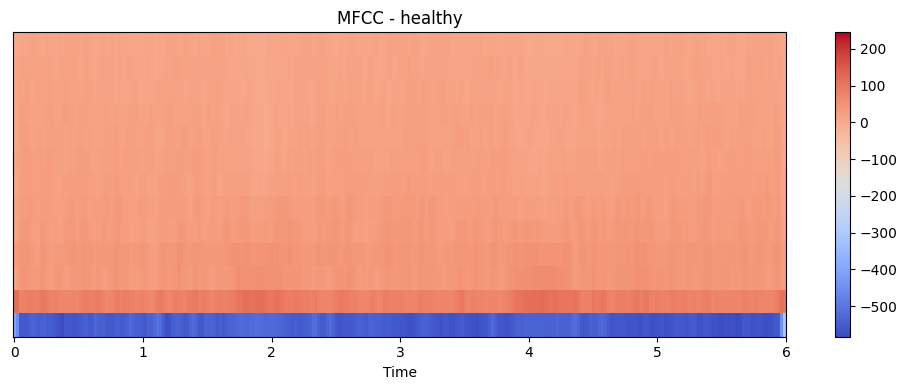

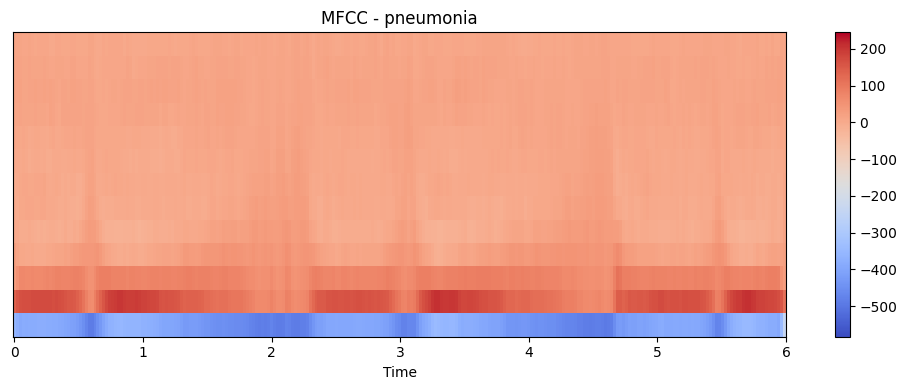

In [ ]:
# MFCC, maybe a paramétriser pour tester plusieurs MFCC

def show_mfcc_examples(base_data_dir="data", index=0, categories=None):
    base_data_dir = Path(base_data_dir)

    if categories is None:
        categories = ["asthma", "Bronchial", "copd", "healthy", "pneumonia"]

    category_dirs = [base_data_dir / category for category in categories]

    print("\n=== MFCC Examples for Each Category (Normalized Color Scale) ===")
    loaded_mfcc = []

    for category_dir in category_dirs:
        if not category_dir.exists():
            print(f"Folder not found: {category_dir}")
            continue

        wav_files = sorted(category_dir.glob("*.wav"))
        if not wav_files:
            print(f"No .wav file in: {category_dir}")
            continue

        audio_path = wav_files[index]  # file at the specified index for this category
        y, sr = librosa.load(str(audio_path), sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13) # n_mfcc : entre 20 et 40 pour le medical poumon
        loaded_mfcc.append((category_dir.name, mfcc, sr))

    if not loaded_mfcc:
        print("No MFCC could be loaded from this dataset.")
        return []

    global_vmin = min(float(np.min(mfcc)) for _, mfcc, _ in loaded_mfcc)
    global_vmax = max(float(np.max(mfcc)) for _, mfcc, _ in loaded_mfcc)

    for category_name, mfcc, sr in loaded_mfcc:
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(
            mfcc,
            sr=sr,
            x_axis="time",
            vmin=global_vmin,
            vmax=global_vmax,
        )
        plt.colorbar()
        plt.title(f"MFCC - {category_name}")
        plt.tight_layout()
        plt.show()

    # return loaded_mfcc

show_mfcc_examples(base_data_dir="data_updated")


=== Log Power Spectrogram Examples for Each Category ===


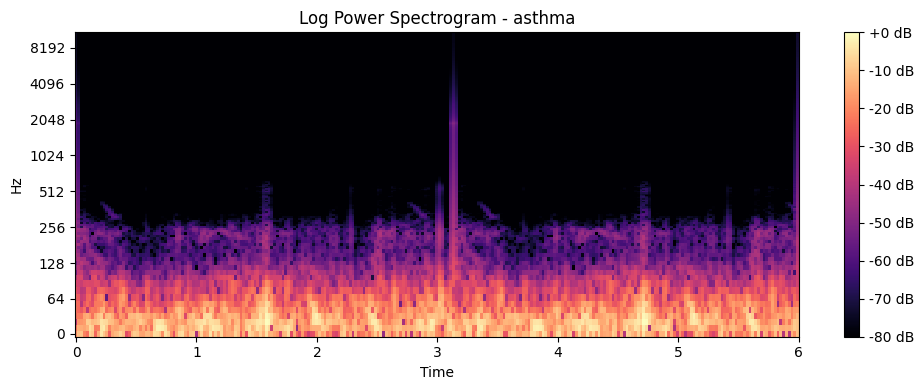

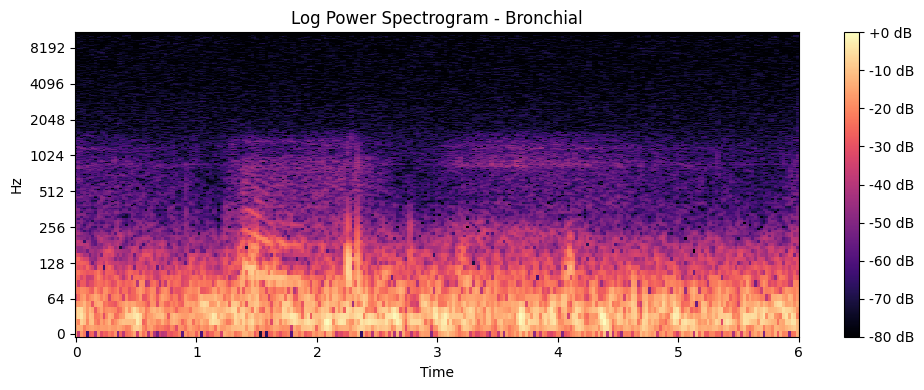

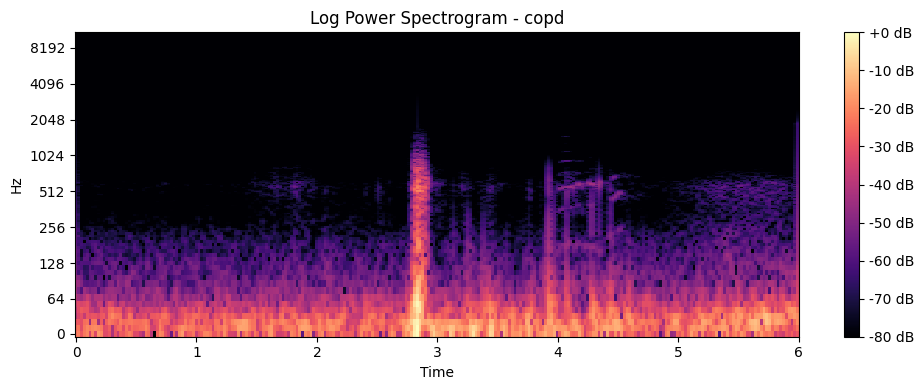

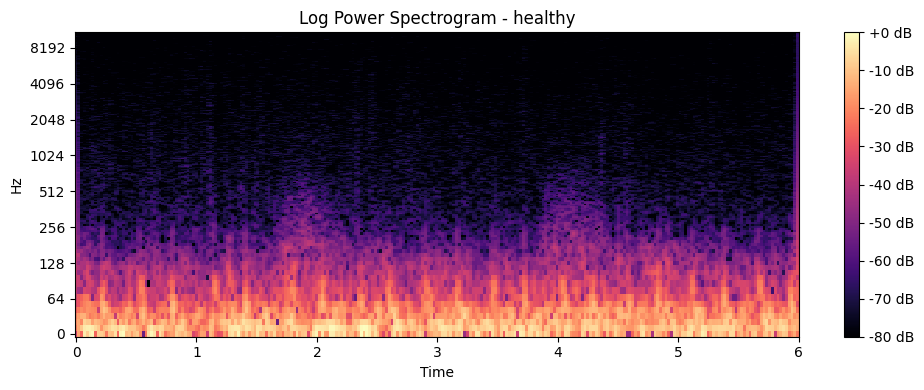

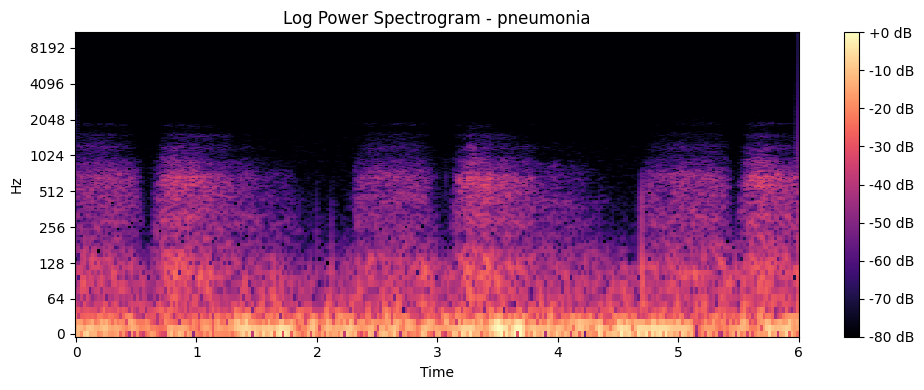

In [11]:
def show_log_power_spectrogram_examples(base_data_dir="data", index=0, categories=None):
    base_data_dir = Path(base_data_dir)

    if categories is None:
        categories = ["asthma", "Bronchial", "copd", "healthy", "pneumonia"]

    category_dirs = [base_data_dir / category for category in categories]

    print("\n=== Log Power Spectrogram Examples for Each Category ===")
    loaded_log_specs = []

    for category_dir in category_dirs:
        if not category_dir.exists():
            print(f"Folder not found: {category_dir}")
            continue

        wav_files = sorted(category_dir.glob("*.wav"))
        if not wav_files:
            print(f"No .wav file in: {category_dir}")
            continue

        if index >= len(wav_files):
            print(f"Index {index} out of range for {category_dir} (files: {len(wav_files)})")
            continue

        audio_path = wav_files[index]
        y, sr = librosa.load(str(audio_path), sr=None)

        D = np.abs(librosa.stft(y)) ** 2
        log_power_spectrogram = librosa.power_to_db(D, ref=np.max)
        loaded_log_specs.append((category_dir.name, log_power_spectrogram, sr))

    if not loaded_log_specs:
        print("No log power spectrogram could be loaded from this dataset.")
        return []

    global_vmin = min(float(np.min(log_spec)) for _, log_spec, _ in loaded_log_specs)
    global_vmax = max(float(np.max(log_spec)) for _, log_spec, _ in loaded_log_specs)

    for category_name, log_spec, sr in loaded_log_specs:
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(
            log_spec,
            sr=sr,
            x_axis="time",
            y_axis="log",
            vmin=global_vmin,
            vmax=global_vmax,
        )
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Log Power Spectrogram - {category_name}")
        plt.tight_layout()
        plt.show()

    # return loaded_log_specs

show_log_power_spectrogram_examples(base_data_dir="data_updated")


=== Zero Crossing Rate Examples for Each Category ===


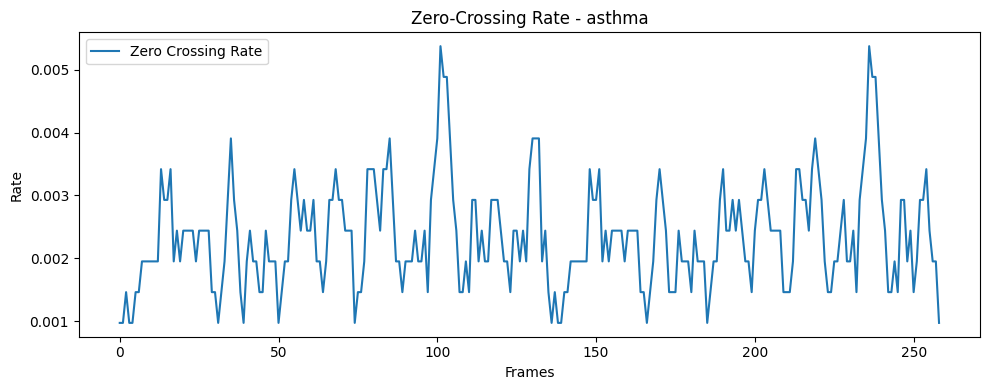

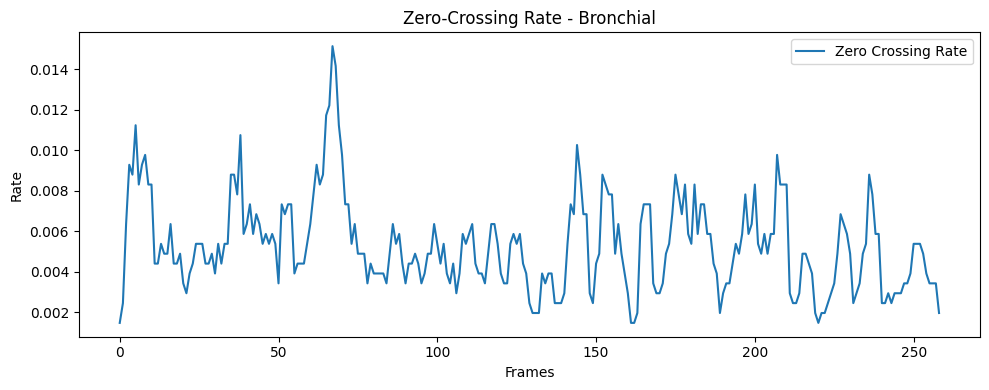

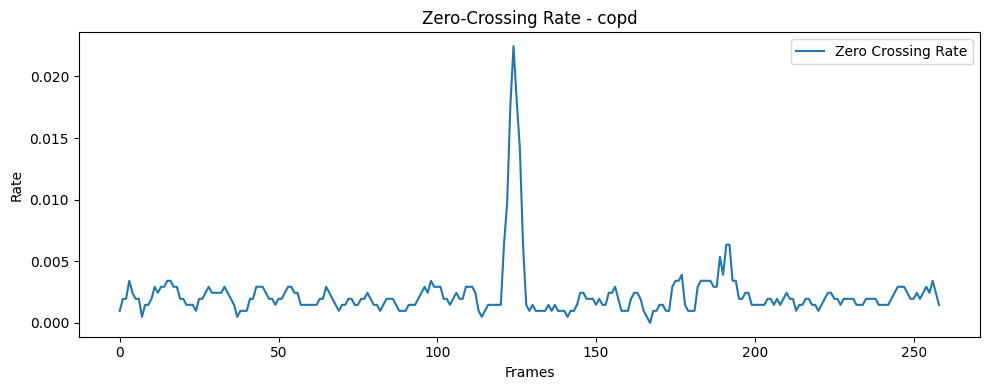

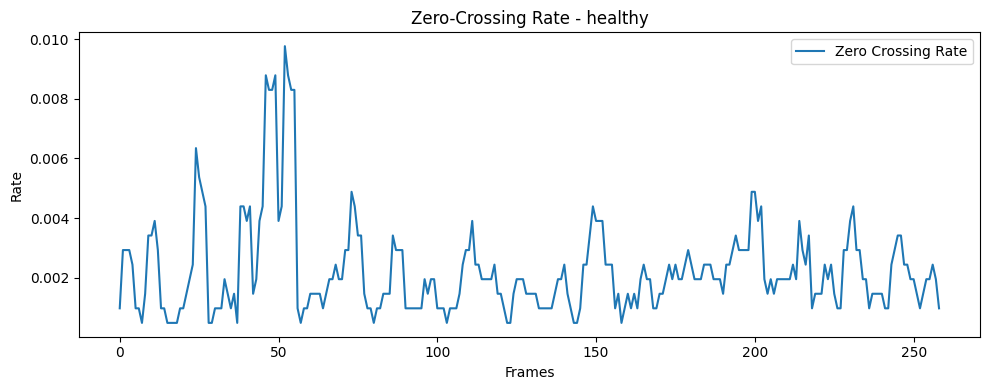

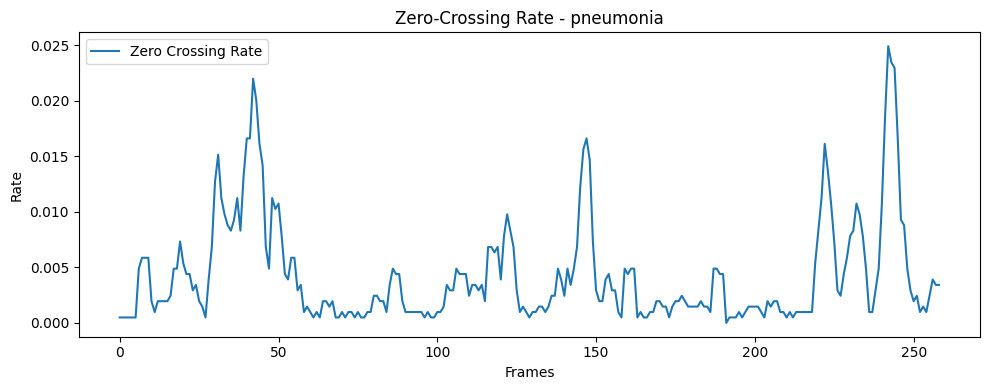

In [12]:
def show_zero_crossing_rate_examples(base_data_dir="data", index=0, categories=None):
    base_data_dir = Path(base_data_dir)

    if categories is None:
        categories = ["asthma", "Bronchial", "copd", "healthy", "pneumonia"]

    category_dirs = [base_data_dir / category for category in categories]

    print("\n=== Zero Crossing Rate Examples for Each Category ===")
    loaded_zcr = []

    for category_dir in category_dirs:
        if not category_dir.exists():
            print(f"Folder not found: {category_dir}")
            continue

        wav_files = sorted(category_dir.glob("*.wav"))
        if not wav_files:
            print(f"No .wav file in: {category_dir}")
            continue

        if index >= len(wav_files):
            print(f"Index {index} out of range for {category_dir} (files: {len(wav_files)})")
            continue

        audio_path = wav_files[index]
        y, sr = librosa.load(str(audio_path), sr=None)

        zero_crossings = librosa.feature.zero_crossing_rate(y)[0]
        loaded_zcr.append((category_dir.name, zero_crossings, sr))

    if not loaded_zcr:
        print("No zero crossing rate could be loaded from this dataset.")
        return []

    for category_name, zero_crossings, _ in loaded_zcr:
        plt.figure(figsize=(10, 4))
        plt.plot(zero_crossings, label="Zero Crossing Rate")
        plt.xlabel("Frames")
        plt.ylabel("Rate")
        plt.title(f"Zero-Crossing Rate - {category_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # return loaded_zcr

show_zero_crossing_rate_examples(base_data_dir="data_updated")


=== Chroma Feature Examples for Each Category ===


c:\Users\Paul\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


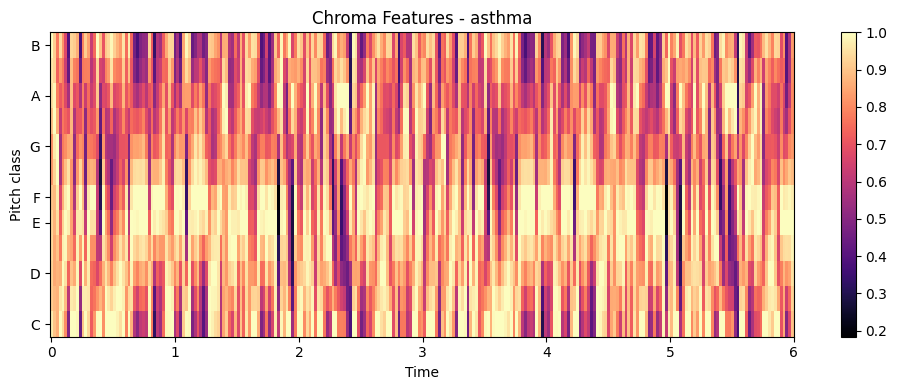

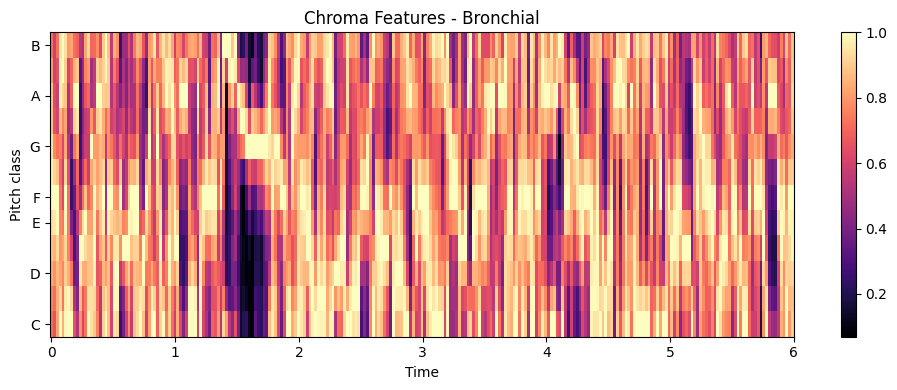

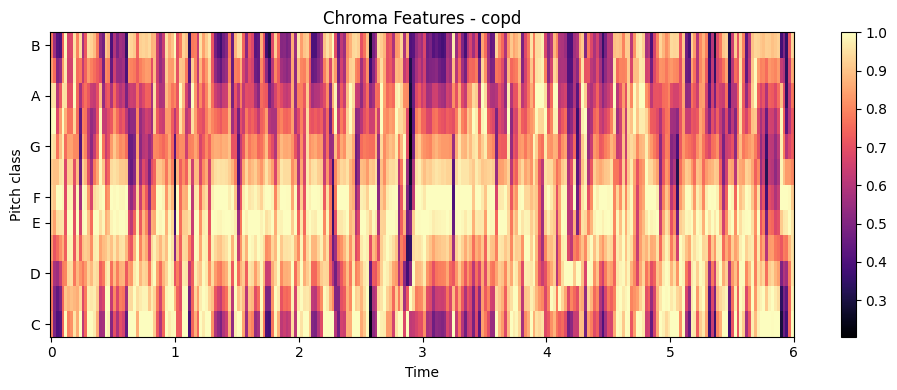

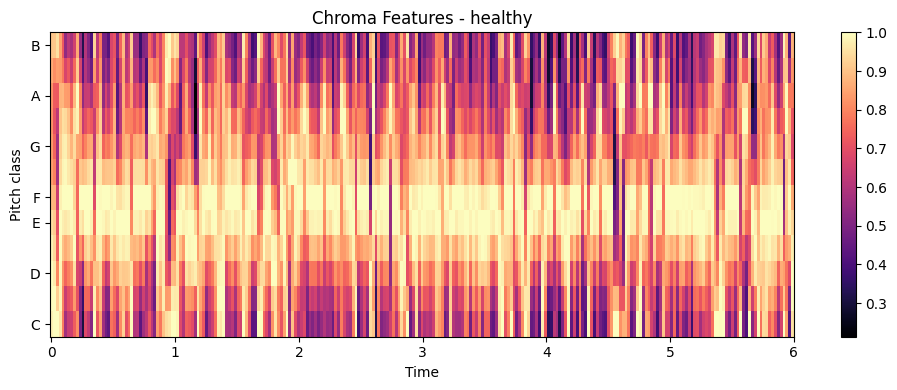

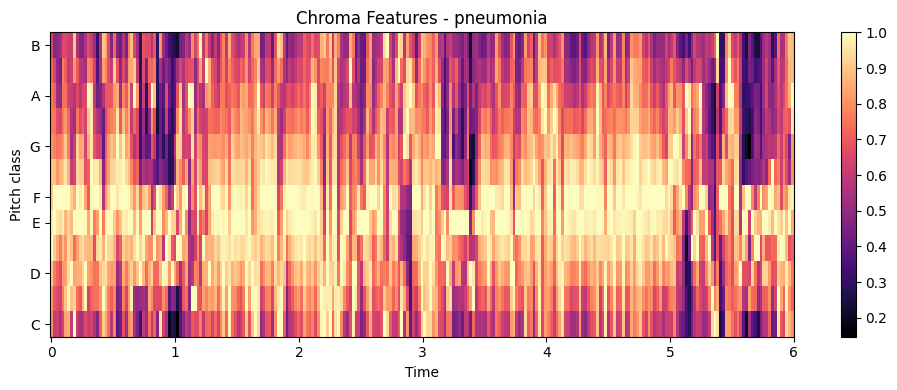

In [13]:
def show_chroma_feature_examples(base_data_dir="data", index=0, categories=None):
    base_data_dir = Path(base_data_dir)

    if categories is None:
        categories = ["asthma", "Bronchial", "copd", "healthy", "pneumonia"]

    category_dirs = [base_data_dir / category for category in categories]

    print("\n=== Chroma Feature Examples for Each Category ===")
    loaded_chroma = []

    for category_dir in category_dirs:
        if not category_dir.exists():
            print(f"Folder not found: {category_dir}")
            continue

        wav_files = sorted(category_dir.glob("*.wav"))
        if not wav_files:
            print(f"No .wav file in: {category_dir}")
            continue

        if index >= len(wav_files):
            print(f"Index {index} out of range for {category_dir} (files: {len(wav_files)})")
            continue

        audio_path = wav_files[index]
        y, sr = librosa.load(str(audio_path), sr=None)

        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        loaded_chroma.append((category_dir.name, chroma, sr))

    if not loaded_chroma:
        print("No chroma feature could be loaded from this dataset.")
        return []

    for category_name, chroma, sr in loaded_chroma:
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(chroma, sr=sr, x_axis="time", y_axis="chroma")
        plt.colorbar()
        plt.title(f"Chroma Features - {category_name}")
        plt.tight_layout()
        plt.show()

    # return loaded_chroma

show_chroma_feature_examples(base_data_dir="data_updated")

# Pré-traitement

### Fixer sample_rate et durée

In [14]:
from pathlib import Path
import numpy as np
import librosa
import soundfile as sf
import pandas as pd

def preprocess_audio_dataset(target_sr: int, target_duration_sec: float, input_root: str = "data"):
    input_root = Path(input_root)
    output_root = Path(f"data_updated")
    output_root.mkdir(parents=True, exist_ok=True)

    target_samples = int(target_sr * target_duration_sec)
    rows = []

    for src_wav in input_root.rglob("*.wav"):
        rel_path = src_wav.relative_to(input_root)
        dst_wav = output_root / rel_path
        dst_wav.parent.mkdir(parents=True, exist_ok=True)

        y, _ = librosa.load(str(src_wav), sr=target_sr, mono=True)
        original_samples = len(y)

        if original_samples == 0:
            y_fixed = np.zeros(target_samples, dtype=np.float32)
            action = "silence_fill"
        elif original_samples < target_samples:
            repeats = int(np.ceil(target_samples / original_samples))
            y_fixed = np.tile(y, repeats)[:target_samples]
            action = "looped"
        elif original_samples > target_samples:
            y_fixed = y[:target_samples]
            action = "trimmed"
        else:
            y_fixed = y
            action = "unchanged"

        sf.write(str(dst_wav), y_fixed, target_sr)

        rows.append(
            {
                "file": str(rel_path).replace("\\", "/"),
                "orig_duration_sec": round(original_samples / target_sr, 4),
                "new_duration_sec": round(len(y_fixed) / target_sr, 4),
                "action": action,
            }
        )

    fix_duration_df = pd.DataFrame(rows)
    return fix_duration_df, output_root

fix_duration_df, output_root = preprocess_audio_dataset(target_sr=22050, target_duration_sec=6)

print(f"Processed files: {len(fix_duration_df)}")
print("Output folder:", output_root)
print("Action counts:")
print(fix_duration_df["action"].value_counts())

fix_duration_df.head()

Processed files: 1211
Output folder: data_updated
Action counts:
action
unchanged    1106
looped        105
Name: count, dtype: int64


,file,orig_duration_sec,new_duration_sec,action
0,asthma/P10AsthmaIE_49.wav,3.136,6.0,looped
1,asthma/P10AsthmaIU_46.wav,4.944,6.0,looped
2,asthma/P10AsthmaIU_50.wav,6.000,6.0,unchanged
3,asthma/P10AsthmaRL_47.wav,6.000,6.0,unchanged
4,asthma/P10AsthmaRS_48.wav,6.000,6.0,unchanged


### Visualisation


=== Mel Spectrogram Examples for Each Category (Normalized Color Scale) ===


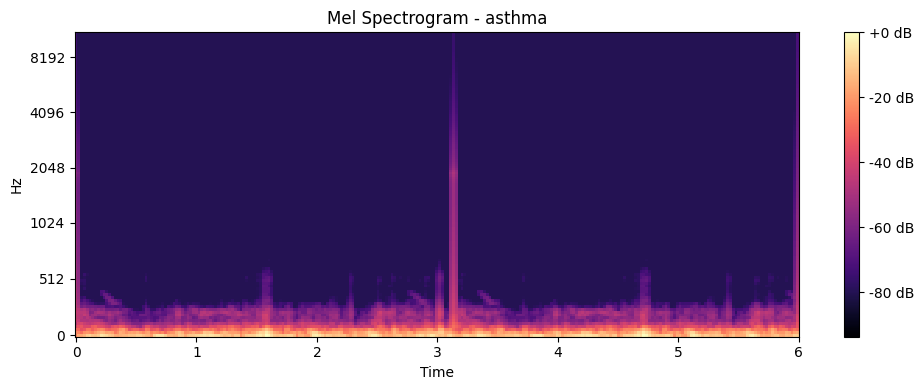

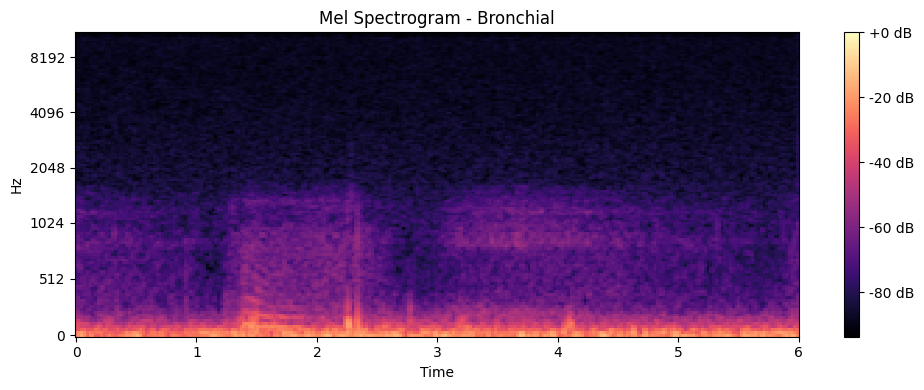

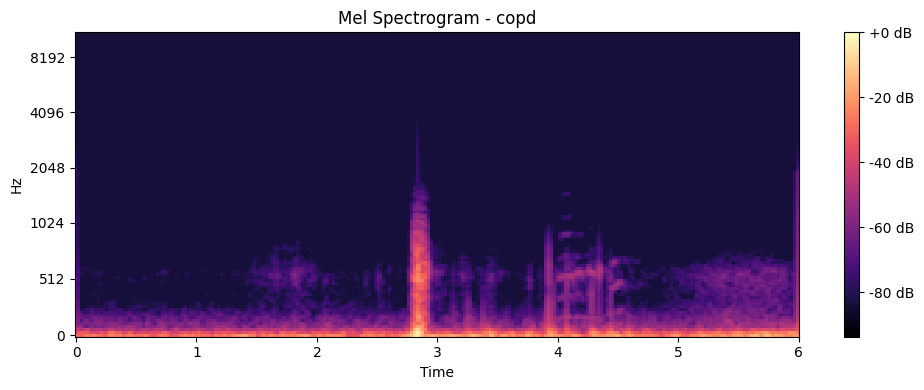

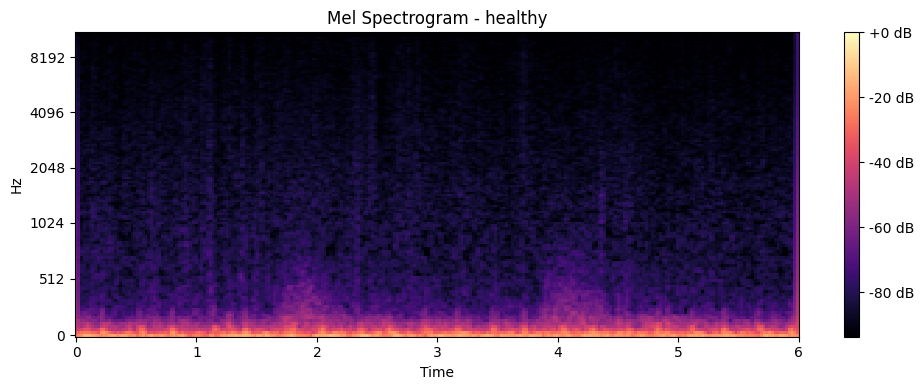

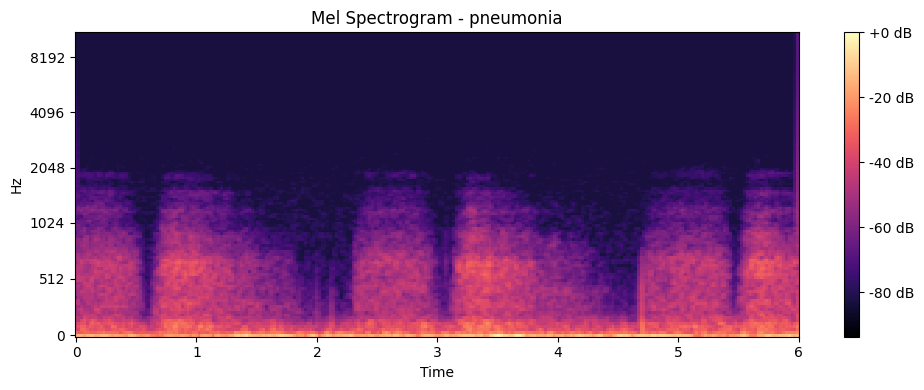

In [15]:
show_mel_spectrogram_examples(base_data_dir="data_updated")